In [1]:
import rioxarray
import rasterio
from rasterio import features
from rasterio.features import shapes
import geopandas as gpd

In [2]:
# Load band data
# Time 1:
#red_2014 = rioxarray.open_rasterio(r"C:/Users/cclark/Documents/408/Final_Project/Data/Jan_2014_Data/LC08_L1TP_030036_20140111_20200912_02_T1_B4.TIF")
IR_2014 = rioxarray.open_rasterio(r"C:/Users/cclark/Documents/408/Final_Project/Data/Jan_2014_Data/LC08_L1TP_030036_20140111_20200912_02_T1_B5.TIF")
# Time 2:
red_2026 = rioxarray.open_rasterio(r"C:/Users/cclark/Documents/408/Final_Project/Data/Jan_2026_Data/LC09_L1TP_030036_20260120_20260120_02_T1_B4.TIF")
IR_2026 = rioxarray.open_rasterio(r"C:/Users/cclark/Documents/408/Final_Project/Data/Jan_2026_Data/LC09_L1TP_030036_20260120_20260120_02_T1_B5.TIF")

In [3]:
with rasterio.open("C:/Users/cclark/Documents/408/Final_Project/Data/Jan_2014_Data/LC08_L1TP_030036_20140111_20200912_02_T1_B4.TIF") as src:
    image = src.read(1)
    mask = image != src.nodata

    results = (
        {"properties": {"raster_val": v}, "geometry": s}
        for i, (s,v) in enumerate(
            features.shapes(image, mask=mask, transform=src.transform)
        )
    )

geoms = list(results)
df = gpd.GeoDataFrame.from_features(geoms)

KeyboardInterrupt: 

In [ ]:
clipped_2014 = raster.rio.clip(IR_2014.geometry

In [77]:
# Calculate NDVI
ndvi_2014 = (IR_2014 - red_2014)/(IR_2014 + red_2014)
ndvi_2026 = (IR_2026 - red_2026)/(IR_2026 + red_2026)

In [78]:
# Filter out irrigated farmland
ndvi_2014_filtered = ndvi_2014.where(ndvi_2014 < 0.15)
ndvi_2026_filtered = ndvi_2026.where(ndvi_2026 < 0.15)

In [79]:
ndvi_2026_filtered.rio.to_raster("2026_ndvi_filtered.tif")
ndvi_2014_filtered.rio.to_raster("2014_ndvi_filtered.tif")

In [81]:
ndvi_diff = ndvi_2026_filtered - ndvi_2014_filtered

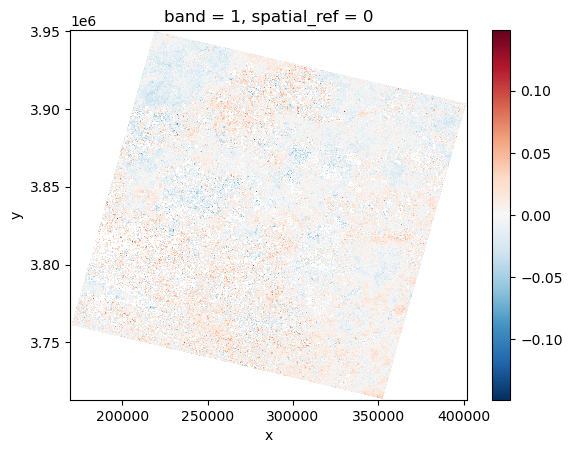

In [82]:
ndvi_diff.plot()